In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
Cloning into 'classification-of-medical-images-using-cnn'...
remote: Enumerating objects: 890, done.
remote: Counting objects: 100% (278/278), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 890 (delta 124), reused 223 (delta 88), pack-reused 612 (from 1)
Receiving objects: 100% (890/890), 7.74 MiB | 17.89 MiB/s, done.
Resolving deltas: 100% (450/450), done.
/content/classification-of-medical-images-using-cnn


In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Mounted at /content/drive


In [ ]:
experiment_names = ["efficientnet-baseline", "efficientnet-rescaling",
                  "densenet-baseline", "densenet-rescaling",
                  "resnet-baseline", "resnet-rescaling"]
COMPARISON_PATH = "comparisons/01-normalization"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

In [5]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)

In [6]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
efficientnet-baseline,0.866987,0.022664,0.848382,0.044925,0.964103,0.025726,0.901138,0.013308,0.705128,0.102979,0.961047,0.002615
efficientnet-rescaling,0.625000,0.000000,0.625000,0.000000,1.000000,0.000000,0.769231,0.000000,0.000000,0.000000,0.731613,0.008947
densenet-baseline,0.855769,0.019275,0.831175,0.031108,0.968376,0.017433,0.893862,0.010904,0.668091,0.080355,0.956991,0.001435
densenet-rescaling,0.868590,0.008172,0.854218,0.021024,0.953846,0.025470,0.900726,0.005511,0.726496,0.051401,0.941248,0.005152
resnet-baseline,0.879808,0.024234,0.885167,0.056200,0.936752,0.042306,0.907570,0.013514,0.784900,0.129684,0.954208,0.005962
resnet-rescaling,0.777778,0.032642,0.771846,0.046421,0.924786,0.034038,0.839492,0.015294,0.532764,0.139150,0.880039,0.004703


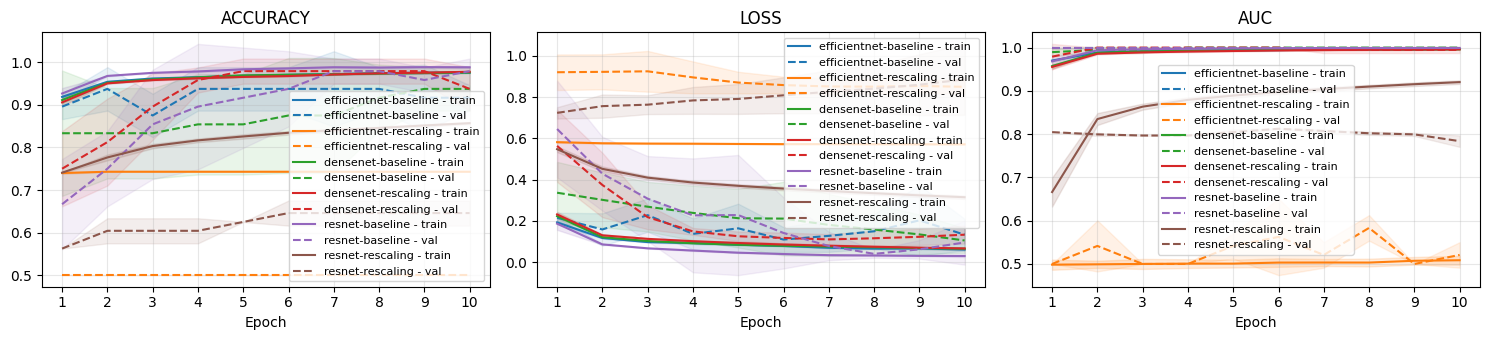

In [7]:
from src.analyses import plot_training_history
import matplotlib.pyplot as plt

fig = plot_training_history(experiments)

plt.show()

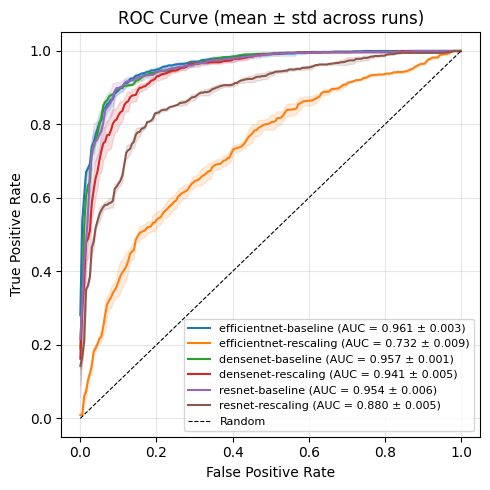

In [8]:
from src.analyses import plot_roc_curves

fig = plot_roc_curves(experiments)

plt.show()

In [9]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  show_plot=False,
  save_dir=SAVE_DIR
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/01-normalization


Faz upload da tabela e dos gráficos das comparações para o DagsHub

In [11]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))


dagshub.upload_files(
    "amartinsmg/classification-of-medical-images-using-cnn",
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)

Output()

Directory upload complete, uploaded 4 files to 
https://dagshub.com/amartinsmg/classification-of-medical-images-using-cnn/src/main/comparisons%2F01-normalization